# Tratamento dos dados


In [52]:
%%html
<link rel="stylesheet" href="./style.css">

In [53]:
from itertools import combinations, product

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import HTML, display
from scipy.stats import chi2_contingency, f_oneway

from columns import categorical_columns, numerical_columns, target_columns
from data import scaled_df


In [54]:
def generate_correlation_matrix(matrix: pd.DataFrame, title: str):
    plt.figure(figsize=(15, 12))
    sns.heatmap(
        matrix,
        # annot=True,  # mostra os valores
        # fmt=".2f",  # duas casas decimais
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()


## Características numéricas


In [55]:
def analyse_numerical_correlation(numerical_columns: pd.Series):

    spearman_correlation = numerical_columns.corr(method="spearman")
    generate_correlation_matrix(
        spearman_correlation, "Matriz de correlação de Spearman"
    )

    pearson_correlation = numerical_columns.corr(method="pearson")
    generate_correlation_matrix(pearson_correlation, "Matriz de correlação de Pearson")

    pearson_correlation_abs = pearson_correlation.abs()
    pairs = (
        pearson_correlation_abs.where(
            np.triu(np.ones(pearson_correlation_abs.shape), k=1).astype(bool)
        )
        .stack()
        .sort_values(ascending=False)
    )
    strong_pairs = pairs[pairs >= 0.8]
    strong_pairs_df = strong_pairs.rename_axis(
        ["Variável 1", "Variável 2"]
    ).reset_index()
    strong_pairs_df.columns = ["Variável 1", "Variável 2", "Correlação"]
    strong_pairs_df["Correlação"] = strong_pairs_df["Correlação"].map(
        lambda x: f"{x:.3f}"
    )

    display(
        HTML(
            """
            <table>
                <caption>Pares fortemente correlacionados (|r| >= 0.8)</caption>
                <thead>
                    <tr>
                        <th>Variável 1</th>
                        <th>Variável 2</th>
                        <th>Correlação</th>
                    </tr>
                </thead>
                <tbody>
            """
            + "".join(
                f"<tr><td>{row[0]}</td><td>{row[1]}</td><td>{row[2]}</td></tr>"
                for row in strong_pairs_df.itertuples(index=False, name=None)
            )
            + """
                </tbody>
            </table>
            """
        )
    )

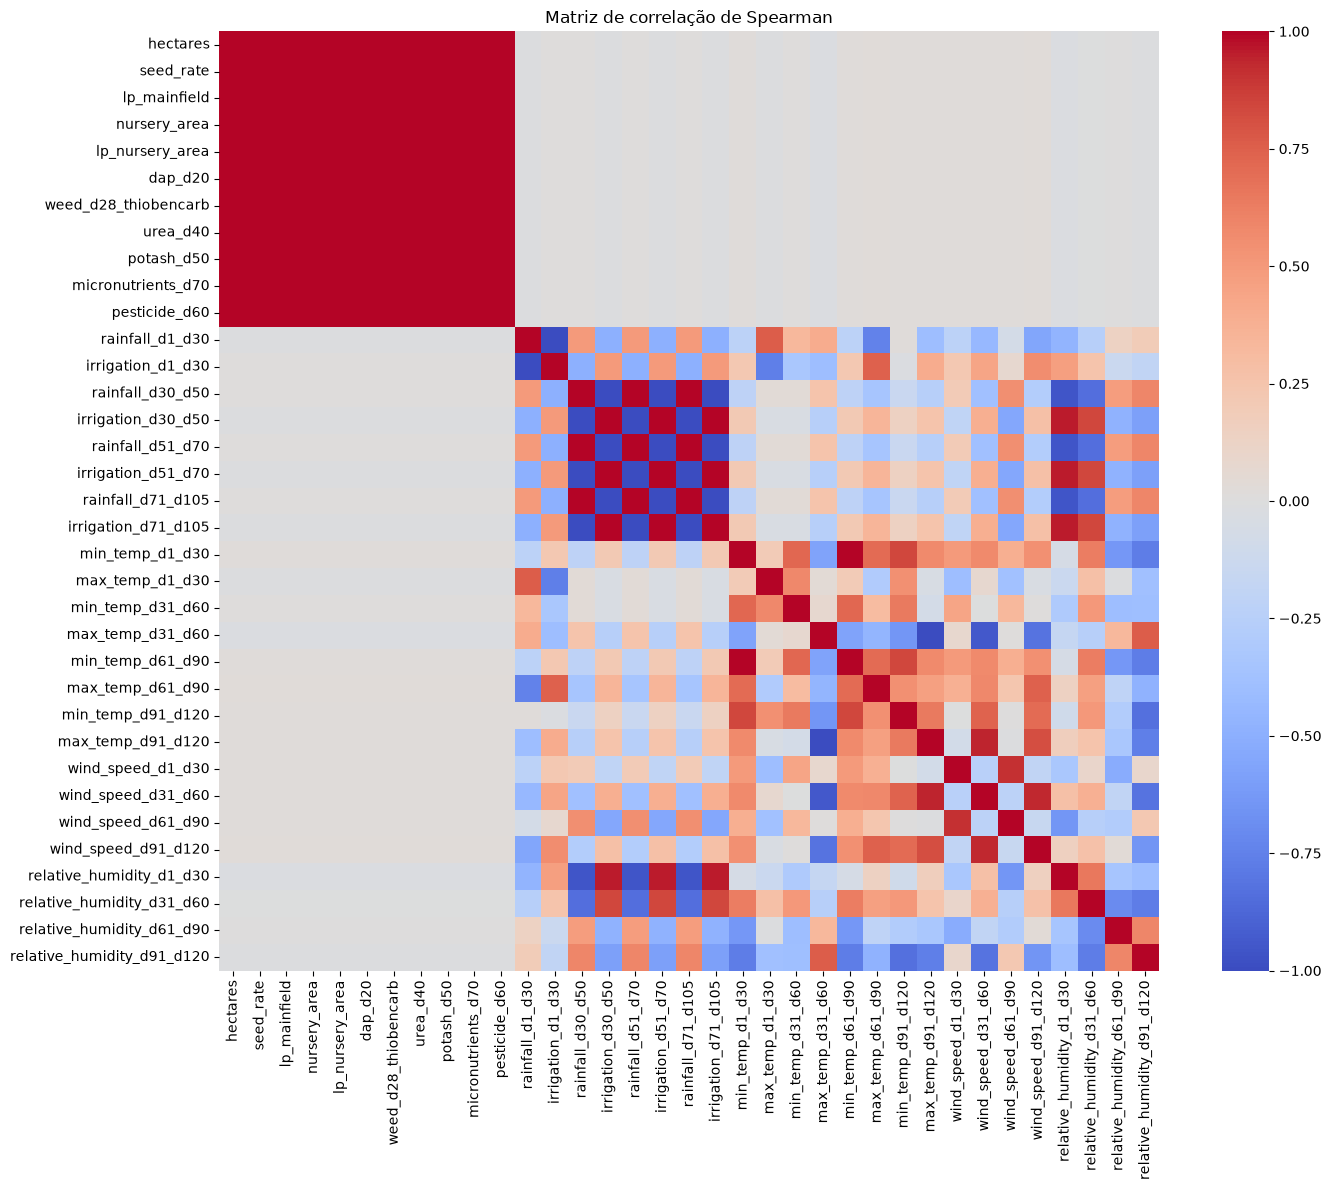

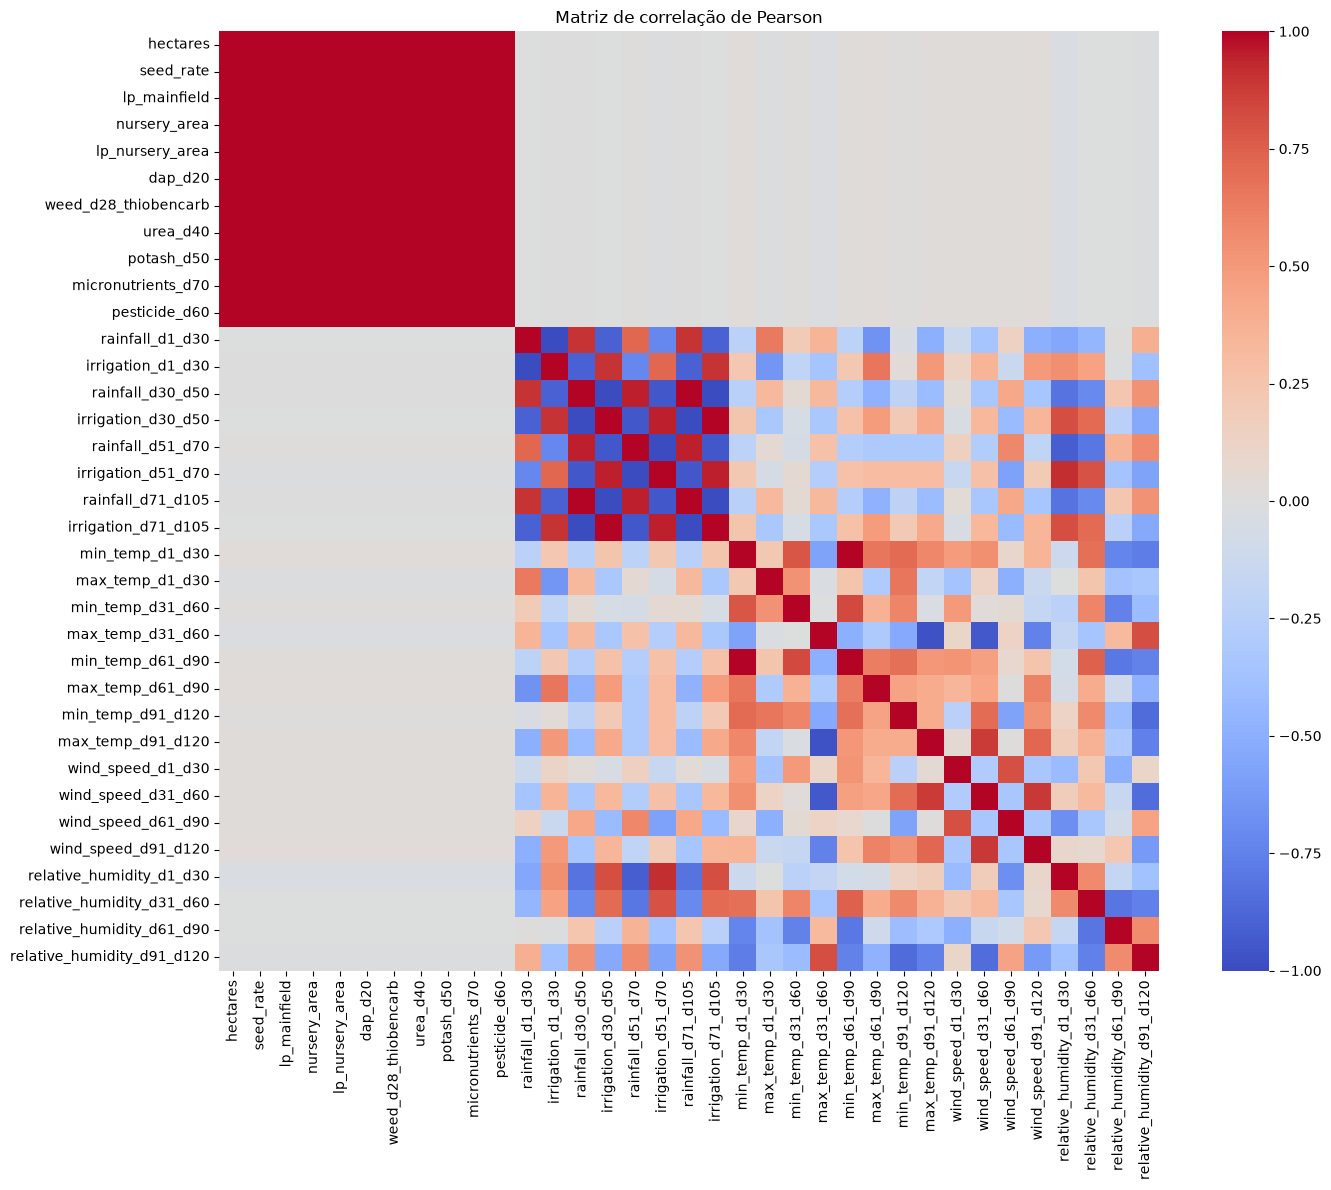

Variável 1,Variável 2,Correlação
hectares,seed_rate,1.000
hectares,lp_mainfield,1.000
seed_rate,lp_mainfield,1.000
seed_rate,urea_d40,1.000
seed_rate,potash_d50,1.000
seed_rate,weed_d28_thiobencarb,1.000
seed_rate,dap_d20,1.000
seed_rate,micronutrients_d70,1.000
seed_rate,pesticide_d60,1.000
lp_mainfield,urea_d40,1.000


In [56]:
analyse_numerical_correlation(numerical_columns=scaled_df[numerical_columns])

### Remoção de características

Foram removidas, por apresentarem correlação de Pearson muito alta, as seguintes características.

- seed_rate
- lp_mainfield
- nursery_area
- lp_nursery_area
- dap_d20
- weed_d28_thiobencarb
- urea_d40
- potash_d50
- micronutrients_d70
- pesticide_d60
- irrigation_d1_d30
- irrigation_d30_d50
- irrigation_d51_d70
- irrigation_d71_d105


### Transformação de características

As seguintes características que apresentam janelas de tempo foram transformadas em duas janelas: uma de curto prazo (01 a 30 dias) e outra de longo prazo (acima de 30 dias).

- rainfall\_[d01_d105]
- min_temp\_[d01_d120]
- max_temp\_[d01_d120]
- wind_speed\_[d01_d120]
- relative_humidity\_[d01_d120]


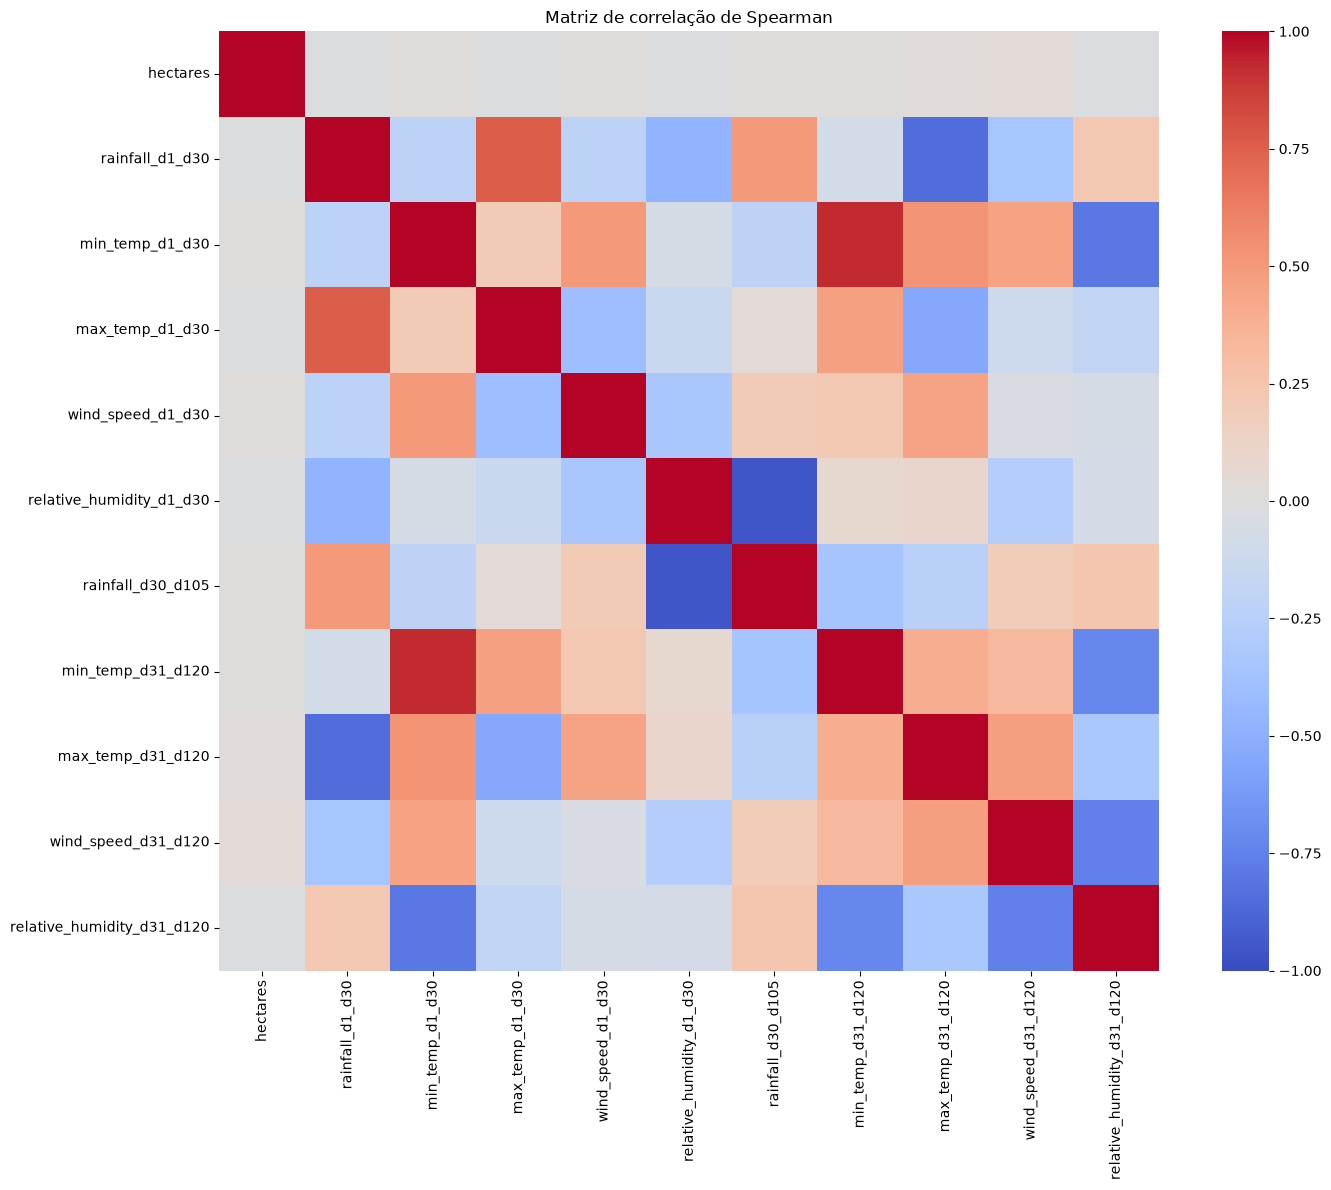

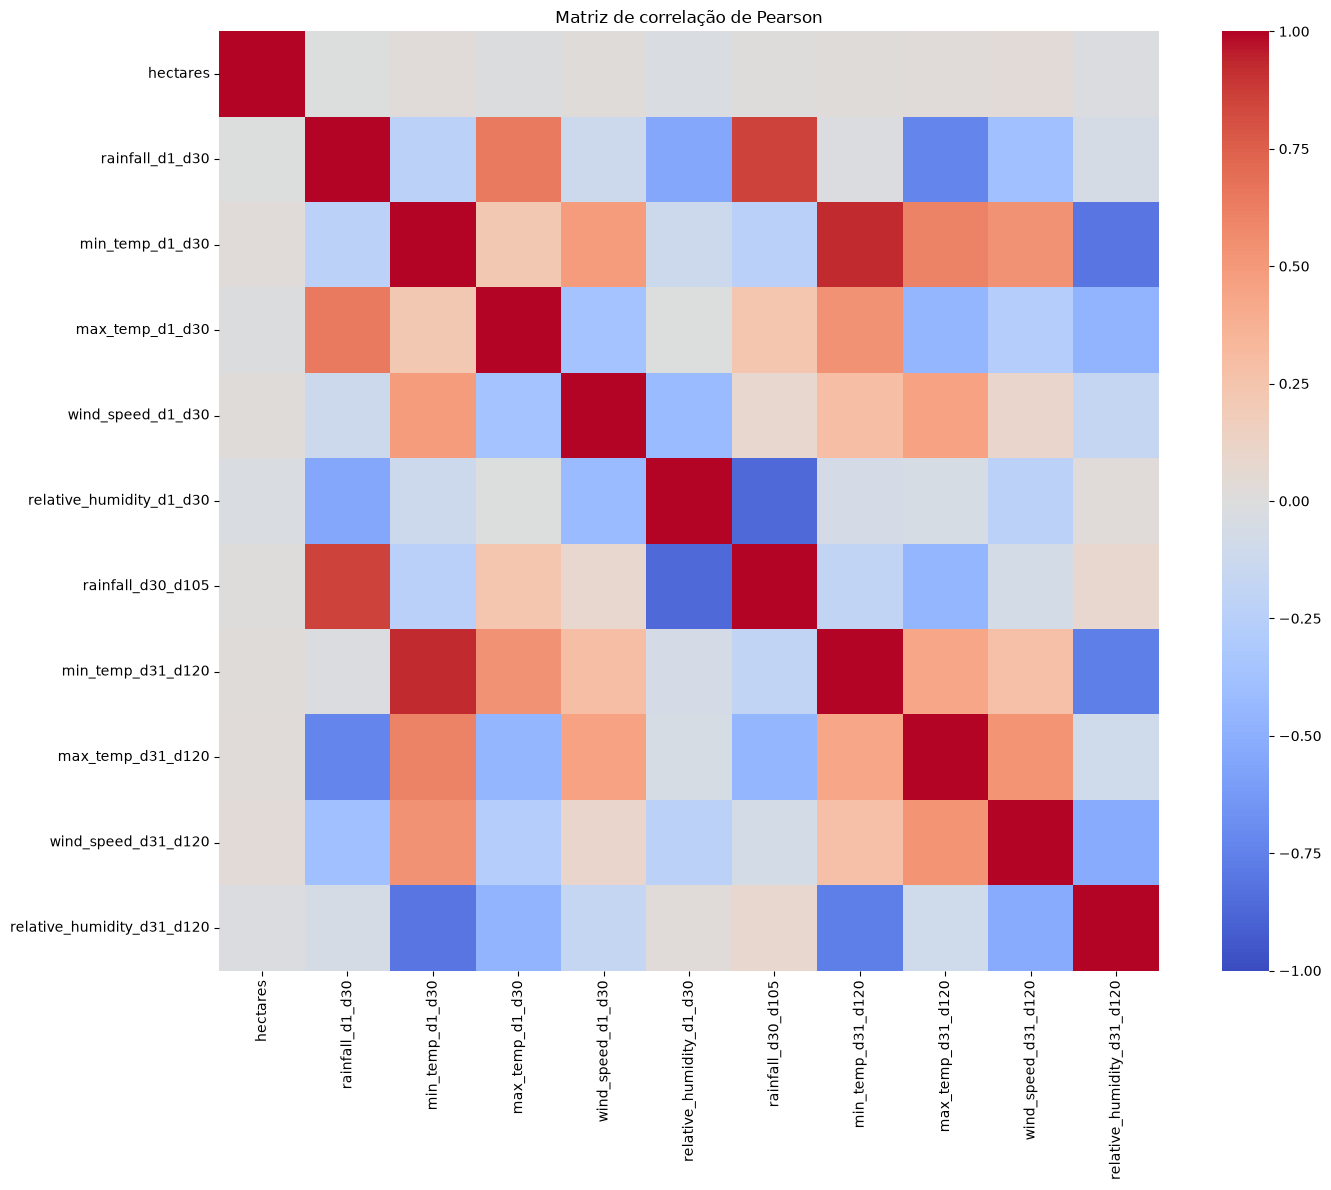

Variável 1,Variável 2,Correlação
min_temp_d1_d30,min_temp_d31_d120,0.923
relative_humidity_d1_d30,rainfall_d30_d105,0.861
rainfall_d1_d30,rainfall_d30_d105,0.852
min_temp_d1_d30,relative_humidity_d31_d120,0.812


In [57]:
f1_df = scaled_df.copy()
f1_numerical_columns = numerical_columns.copy()


def drop_numerical_feature(name: str):
    f1_numerical_columns.remove(name)
    return f1_df.drop(columns=[name])


f1_df = drop_numerical_feature("seed_rate")
f1_df = drop_numerical_feature("lp_mainfield")
f1_df = drop_numerical_feature("nursery_area")
f1_df = drop_numerical_feature("lp_nursery_area")
f1_df = drop_numerical_feature("dap_d20")
f1_df = drop_numerical_feature("weed_d28_thiobencarb")
f1_df = drop_numerical_feature("urea_d40")
f1_df = drop_numerical_feature("potash_d50")
f1_df = drop_numerical_feature("micronutrients_d70")
f1_df = drop_numerical_feature("pesticide_d60")

f1_df["rainfall_d30_d105"] = f1_df[
    ["rainfall_d30_d50", "rainfall_d51_d70", "rainfall_d71_d105"]
].mean(axis=1)
f1_numerical_columns.append("rainfall_d30_d105")
# filtered_df = drop_feature("rainfall_d1_d30")
f1_df = drop_numerical_feature("rainfall_d30_d50")
f1_df = drop_numerical_feature("rainfall_d51_d70")
f1_df = drop_numerical_feature("rainfall_d71_d105")

# filtered_df["irrigation_d30_d105"] = filtered_df[
#     ["irrigation_d30_d50", "irrigation_d51_d70", "irrigation_d71_d105"]
# ].mean(axis=1)
# filtered_numerical_columns.append("irrigation_d30_d105")
f1_df = drop_numerical_feature("irrigation_d1_d30")
f1_df = drop_numerical_feature("irrigation_d30_d50")
f1_df = drop_numerical_feature("irrigation_d51_d70")
f1_df = drop_numerical_feature("irrigation_d71_d105")

f1_df["min_temp_d31_d120"] = f1_df[
    ["min_temp_d31_d60", "min_temp_d61_d90", "min_temp_d91_d120"]
].mean(axis=1)
f1_numerical_columns.append("min_temp_d31_d120")
f1_df = drop_numerical_feature("min_temp_d31_d60")
f1_df = drop_numerical_feature("min_temp_d61_d90")
f1_df = drop_numerical_feature("min_temp_d91_d120")

f1_df["max_temp_d31_d120"] = f1_df[
    ["max_temp_d31_d60", "max_temp_d61_d90", "max_temp_d91_d120"]
].mean(axis=1)
f1_numerical_columns.append("max_temp_d31_d120")
f1_df = drop_numerical_feature("max_temp_d31_d60")
f1_df = drop_numerical_feature("max_temp_d61_d90")
f1_df = drop_numerical_feature("max_temp_d91_d120")

f1_df["wind_speed_d31_d120"] = f1_df[
    ["wind_speed_d31_d60", "wind_speed_d61_d90", "wind_speed_d91_d120"]
].mean(axis=1)
f1_numerical_columns.append("wind_speed_d31_d120")
f1_df = drop_numerical_feature("wind_speed_d31_d60")
f1_df = drop_numerical_feature("wind_speed_d61_d90")
f1_df = drop_numerical_feature("wind_speed_d91_d120")

f1_df["relative_humidity_d31_d120"] = f1_df[
    [
        "relative_humidity_d31_d60",
        "relative_humidity_d61_d90",
        "relative_humidity_d91_d120",
    ]
].mean(axis=1)
f1_numerical_columns.append("relative_humidity_d31_d120")
f1_df = drop_numerical_feature("relative_humidity_d31_d60")
f1_df = drop_numerical_feature("relative_humidity_d61_d90")
f1_df = drop_numerical_feature("relative_humidity_d91_d120")


analyse_numerical_correlation(numerical_columns=f1_df[f1_numerical_columns])

## Características categóricas


In [58]:
def interpret_cramers_v(cramers_v):
    """
    Classifica a intensidade da associação
    com base no V de Cramér.
    """

    if cramers_v < 0.05:
        return "muito fraca"
    elif cramers_v < 0.10:
        return "fraca"
    elif cramers_v < 0.20:
        return "moderada"
    else:
        return "<b>forte</b>"


def chi_square_test(
    data_frame: pd.DataFrame,
    column_1: str,
    column_2: str,
    alpha: float = 0.05,
):

    # Tabela de contingência
    contingency_table = pd.crosstab(
        data_frame[column_1],
        data_frame[column_2],
    )

    # Teste do qui-quadrado
    stat, p, dof, expected = chi2_contingency(contingency_table)

    # Número total de observações
    n = contingency_table.to_numpy().sum()

    # Dimensões da tabela
    rows, columns = contingency_table.shape

    # V de Cramér
    cramers_v = np.sqrt(stat / (n * min(rows - 1, columns - 1)))

    # Intensidade da associação
    association_strength = interpret_cramers_v(cramers_v)

    # Significância estatística
    if p <= alpha:
        significance = "significativa"
    else:
        significance = "não significativa"

    return {
        "Variável 1": column_1,
        "Variável 2": column_2,
        "Chi-quadrado": stat,
        "p-value": p,
        "Graus de liberdade": dof,
        "V de Cramér": cramers_v,
        "Intensidade": association_strength,
        "Associação estatística": significance,
    }


In [59]:
def analyse_categorical_correlation(
    data_frame=pd.DataFrame, categorical_columns=list[str]
):
    results = []

    for column_1, column_2 in combinations(
        categorical_columns,
        2,
    ):
        result = chi_square_test(
            data_frame,
            column_1,
            column_2,
        )

        results.append(result)

    # Transformando os resultados em DataFrame
    results_df = pd.DataFrame(results)

    # ---------------------------------------------------------
    # Formatação do p-value
    # ---------------------------------------------------------

    def format_p_value(p):
        if p < 0.001:
            return "< 0.001"
        else:
            return f"{p:.3f}"

    results_df["p-value"] = results_df["p-value"].apply(format_p_value)

    # Arredondando os demais valores
    results_df["Chi-quadrado"] = results_df["Chi-quadrado"].round(4)

    results_df["V de Cramér"] = results_df["V de Cramér"].round(4)

    # ---------------------------------------------------------
    # Exibindo os resultados
    # ---------------------------------------------------------

    display(HTML("<strong>Resultados das associações</strong>"))

    display(
        results_df.style.format(
            {
                "Chi-quadrado": "{:.4f}",
                "V de Cramér": "{:.4f}",
            }
        )
    )

In [60]:
analyse_categorical_correlation(
    data_frame=f1_df, categorical_columns=categorical_columns
)

,Variável 1,Variável 2,Chi-quadrado,p-value,Graus de liberdade,V de Cramér,Intensidade,Associação estatística
0,agriblock,variety,11.2123,0.341,10,0.0556,fraca,não significativa
1,agriblock,soil_type,7.7268,0.172,5,0.0653,fraca,não significativa
2,agriblock,nursery,1.4048,0.924,5,0.0278,muito fraca,não significativa
3,agriblock,wind_direction_d1_d30,9060.0000,< 0.001,25,1.0000,forte,significativa
4,agriblock,wind_direction_d31_d60,7248.0000,< 0.001,20,1.0000,forte,significativa
5,agriblock,wind_direction_d61_d90,7248.0000,< 0.001,20,1.0000,forte,significativa
6,agriblock,wind_direction_d91_d120,9060.0000,< 0.001,25,1.0000,forte,significativa
7,variety,soil_type,1.0619,0.588,2,0.0242,muito fraca,não significativa
8,variety,nursery,0.0010,0.999,2,0.0007,muito fraca,não significativa
9,variety,wind_direction_d1_d30,11.2123,0.341,10,0.0556,fraca,não significativa


### Remoção de características

Foram removidas, por apresentar correlação forte, as seguintes características.

- wind_direction_d1_d30
- wind_direction_d31_d60
- wind_direction_d61_d90
- wind_direction_d91_d120


In [61]:
f2_df = f1_df.copy()
f2_categorical_columns = categorical_columns.copy()


def drop_categorical_feature(name: str):
    f2_categorical_columns.remove(name)
    return f2_df.drop(columns=[name])


f2_df = drop_categorical_feature("wind_direction_d1_d30")
f2_df = drop_categorical_feature("wind_direction_d31_d60")
f2_df = drop_categorical_feature("wind_direction_d61_d90")
f2_df = drop_categorical_feature("wind_direction_d91_d120")


In [62]:
analyse_categorical_correlation(
    data_frame=f2_df, categorical_columns=f2_categorical_columns
)

,Variável 1,Variável 2,Chi-quadrado,p-value,Graus de liberdade,V de Cramér,Intensidade,Associação estatística
0,agriblock,variety,11.2123,0.341,10,0.0556,fraca,não significativa
1,agriblock,soil_type,7.7268,0.172,5,0.0653,fraca,não significativa
2,agriblock,nursery,1.4048,0.924,5,0.0278,muito fraca,não significativa
3,variety,soil_type,1.0619,0.588,2,0.0242,muito fraca,não significativa
4,variety,nursery,0.0010,0.999,2,0.0007,muito fraca,não significativa
5,soil_type,nursery,1.4138,0.234,1,0.0279,muito fraca,não significativa


## Características categóricas × numéricas


In [63]:
def interpret_eta_squared(eta_squared):

    if eta_squared < 0.01:
        return "muito fraca"

    elif eta_squared < 0.06:
        return "fraca"

    elif eta_squared < 0.14:
        return "moderada"

    else:
        return "<b>forte</b>"


def anova_test(data_frame, categorical_column, numeric_column, alpha=0.05):
    data = data_frame[[categorical_column, numeric_column]].dropna()

    groups = [
        group[numeric_column].values for _, group in data.groupby(categorical_column)
    ]
    number_of_groups = len(groups)
    statistic, p_value = f_oneway(*groups)

    grand_mean = data[numeric_column].mean()
    ss_between = sum(
        len(group) * (np.mean(group) - grand_mean) ** 2 for group in groups
    )
    ss_total = sum((value - grand_mean) ** 2 for value in data[numeric_column])

    eta_squared = ss_between / ss_total
    effect_strength = interpret_eta_squared(eta_squared)

    if p_value <= alpha:
        significance = "significativa"
    else:
        significance = "não significativa"

    return {
        "Variável categórica": categorical_column,
        "Variável numérica": numeric_column,
        "ANOVA": statistic,
        "p-value": p_value,
        "η²": eta_squared,
        "Intensidade": effect_strength,
        "Associação estatística": significance,
        "N categorias": number_of_groups,
    }


In [64]:
def analyse_categorical_and_numerical_correlation(
    data_frame: pd.DataFrame,
    categorical_columns: list[str],
    numerical_columns: list[str],
):
    results = []

    for categorical_column, numerical_column in product(
        categorical_columns, numerical_columns
    ):
        result = anova_test(data_frame, categorical_column, numerical_column)
        results.append(result)

    results_df = pd.DataFrame(results)

    display(
        results_df.style.format(
            {
                "ANOVA": "{:.4f}",
                "p-value": "{:.6f}",
                "η²": "{:.4f}",
            }
        )
    )


analyse_categorical_and_numerical_correlation(
    data_frame=f2_df,
    categorical_columns=f2_categorical_columns,
    numerical_columns=f1_numerical_columns,
)

,Variável categórica,Variável numérica,ANOVA,p-value,η²,Intensidade,Associação estatística,N categorias
0,agriblock,hectares,0.5629,0.728568,0.0016,muito fraca,não significativa,6
1,agriblock,rainfall_d1_d30,inf,0.000000,1.0000,forte,significativa,6
2,agriblock,min_temp_d1_d30,inf,0.000000,1.0000,forte,significativa,6
3,agriblock,max_temp_d1_d30,inf,0.000000,1.0000,forte,significativa,6
4,agriblock,wind_speed_d1_d30,inf,0.000000,1.0000,forte,significativa,6
5,agriblock,relative_humidity_d1_d30,inf,0.000000,1.0000,forte,significativa,6
6,agriblock,rainfall_d30_d105,inf,0.000000,1.0000,forte,significativa,6
7,agriblock,min_temp_d31_d120,inf,0.000000,1.0000,forte,significativa,6
8,agriblock,max_temp_d31_d120,inf,0.000000,1.0000,forte,significativa,6
9,agriblock,wind_speed_d31_d120,inf,0.000000,1.0000,forte,significativa,6


### Remoção de características

A característica categórica `agriblock` representa perfeitamente dado cenário de características climáticas.
Dessa forma, mantemos-no e removemos as seguintes características.

- rainfall_d1_d30
- min_temp_d1_d30
- max_temp_d1_d30
- wind_speed_d1_d30
- relative_humidity_d1_d30
- rainfall_d30_d105
- min_temp_d31_d120
- max_temp_d31_d120
- wind_speed_d31_d120
- relative_humidity_d31_d120


In [65]:
f3_df = f2_df.copy()
f3_numerical_columns = f1_numerical_columns.copy()
f3_categorical_columns = f2_categorical_columns.copy()


def drop_categorical_feature(name: str):
    f3_categorical_columns.remove(name)
    return f3_df.drop(columns=[name])


# f3_df = drop_categorical_feature("agriblock")


def drop_numerical_feature(name: str):
    f3_numerical_columns.remove(name)
    return f3_df.drop(columns=[name])


f3_df = drop_numerical_feature("rainfall_d1_d30")
f3_df = drop_numerical_feature("min_temp_d1_d30")
f3_df = drop_numerical_feature("max_temp_d1_d30")
f3_df = drop_numerical_feature("wind_speed_d1_d30")
f3_df = drop_numerical_feature("relative_humidity_d1_d30")
f3_df = drop_numerical_feature("rainfall_d30_d105")
f3_df = drop_numerical_feature("min_temp_d31_d120")
f3_df = drop_numerical_feature("max_temp_d31_d120")
f3_df = drop_numerical_feature("wind_speed_d31_d120")
f3_df = drop_numerical_feature("relative_humidity_d31_d120")


analyse_categorical_and_numerical_correlation(
    data_frame=f3_df,
    categorical_columns=f3_categorical_columns,
    numerical_columns=f3_numerical_columns,
)

,Variável categórica,Variável numérica,ANOVA,p-value,η²,Intensidade,Associação estatística,N categorias
0,agriblock,hectares,0.5629,0.728568,0.0016,muito fraca,não significativa,6
1,variety,hectares,0.3667,0.693073,0.0004,muito fraca,não significativa,3
2,soil_type,hectares,0.4942,0.482165,0.0003,muito fraca,não significativa,2
3,nursery,hectares,0.0577,0.810215,0.0000,muito fraca,não significativa,2


## Resultado


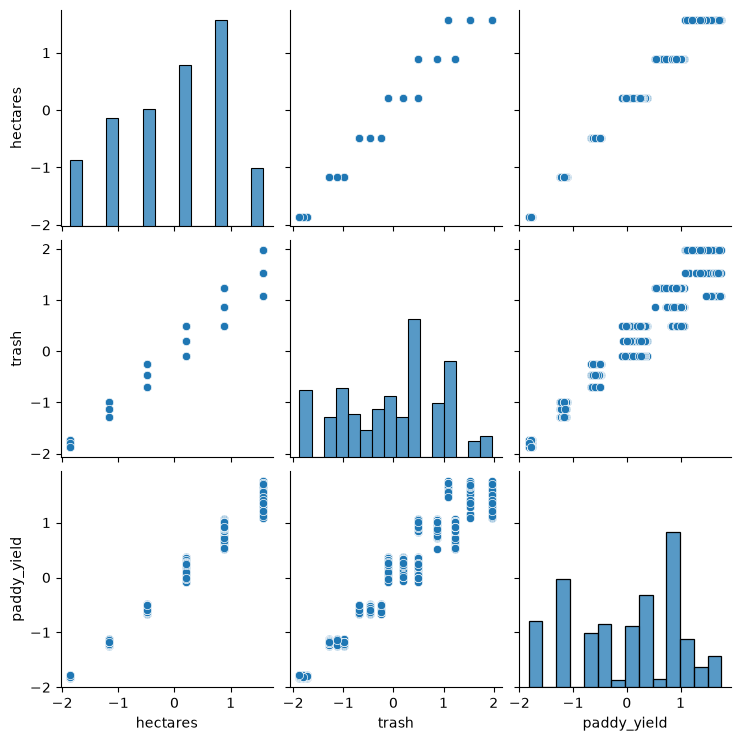

In [66]:
sns.pairplot(f3_df[[*f3_numerical_columns, *target_columns]], diag_kind="hist")

plt.show()

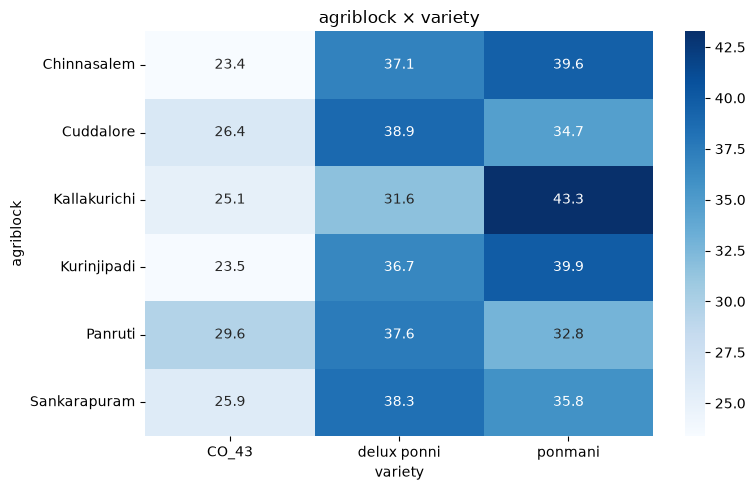

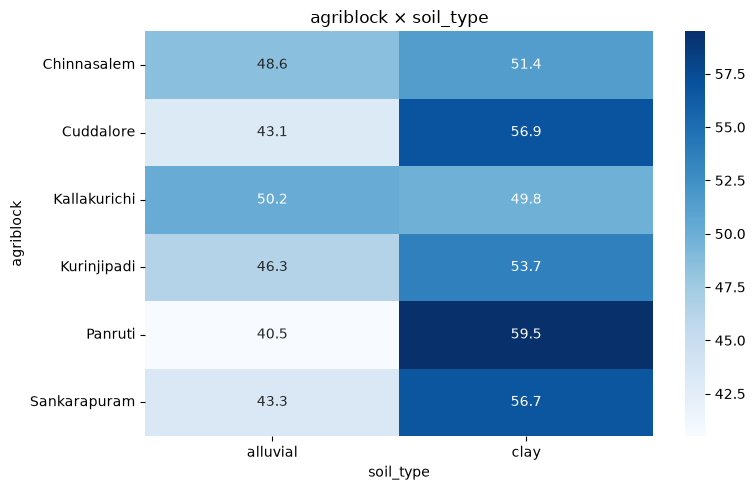

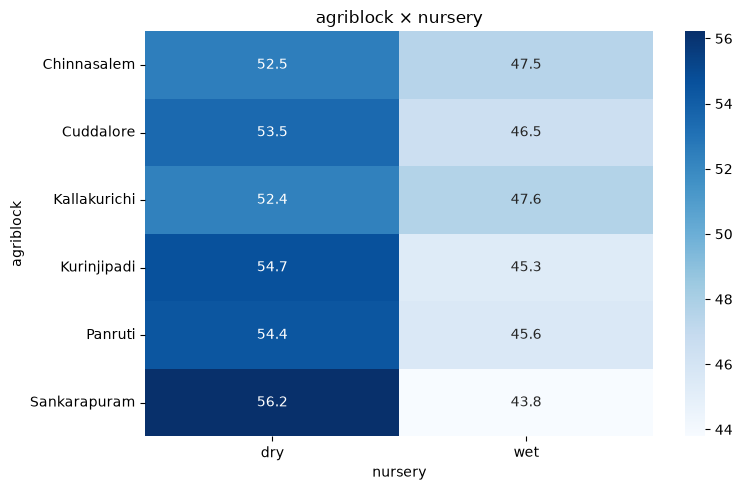

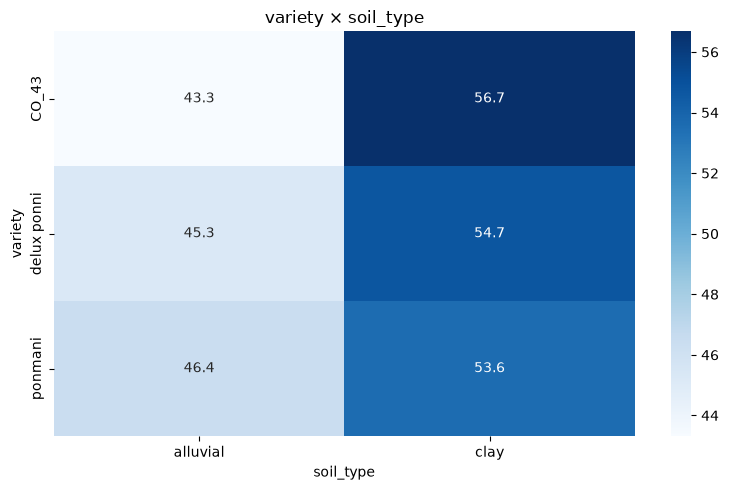

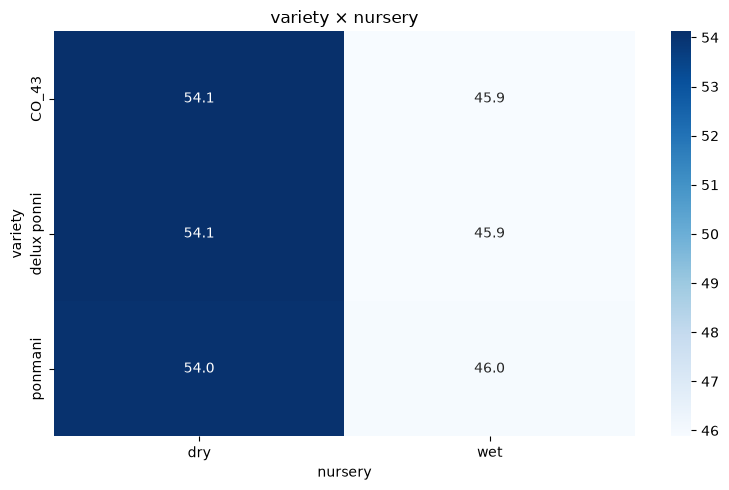

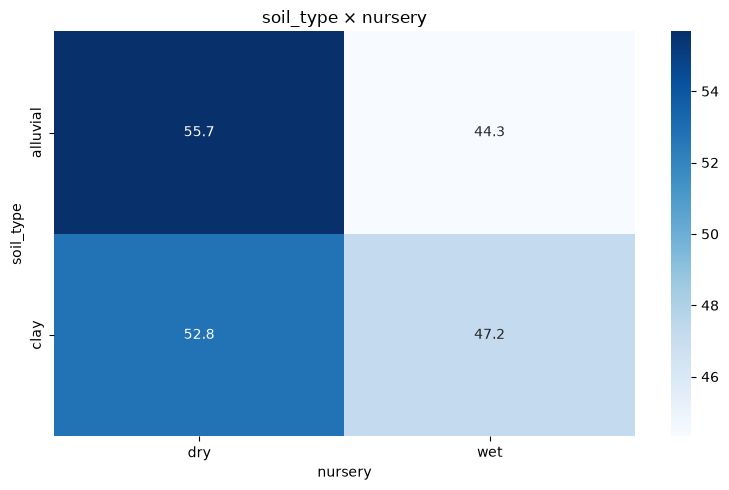

In [67]:
def plot_categorical_relationships(
    data_frame: pd.DataFrame, categorical_columns: list[str]
):
    pairs = list(combinations(categorical_columns, 2))

    for column_1, column_2 in pairs:
        # Tabela de proporções
        table = (
            pd.crosstab(data_frame[column_1], data_frame[column_2], normalize="index")
            * 100
        )

        plt.figure(figsize=(8, 5))

        sns.heatmap(table, annot=True, fmt=".1f", cmap="Blues")

        plt.title(f"{column_1} × {column_2}")
        plt.xlabel(column_2)
        plt.ylabel(column_1)

        plt.tight_layout()
        plt.show()


plot_categorical_relationships(
    data_frame=f3_df, categorical_columns=f3_categorical_columns
)

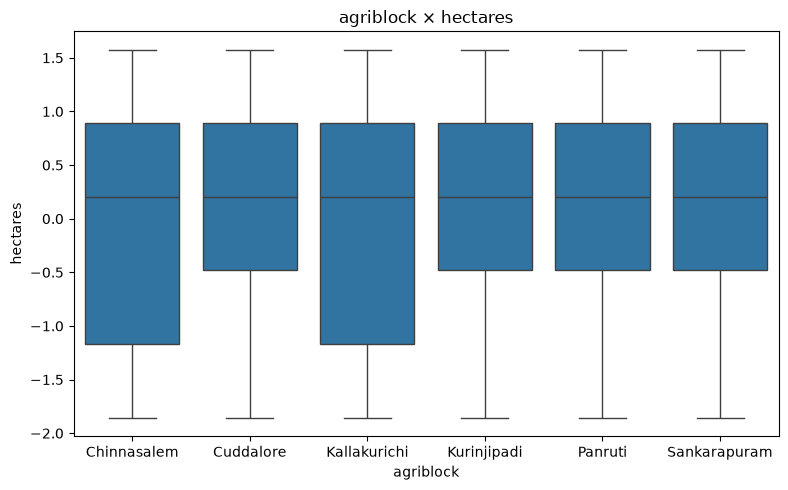

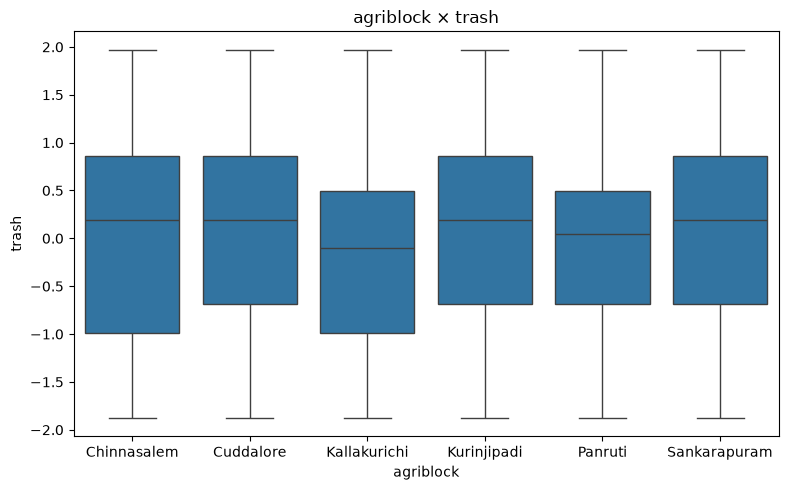

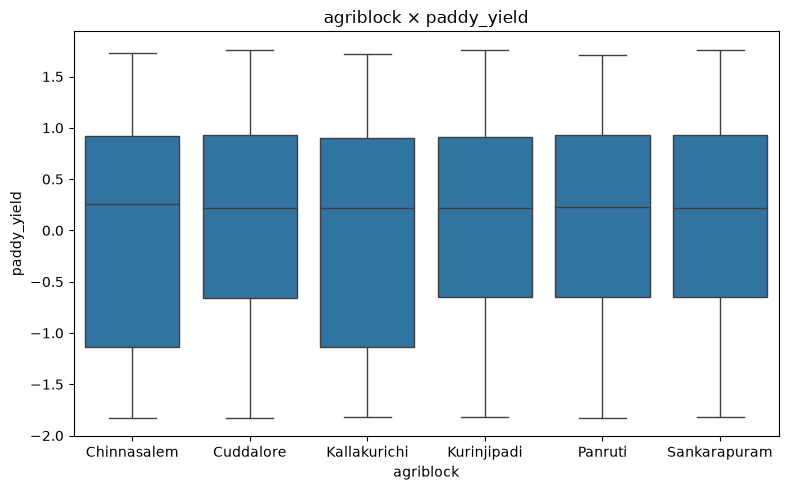

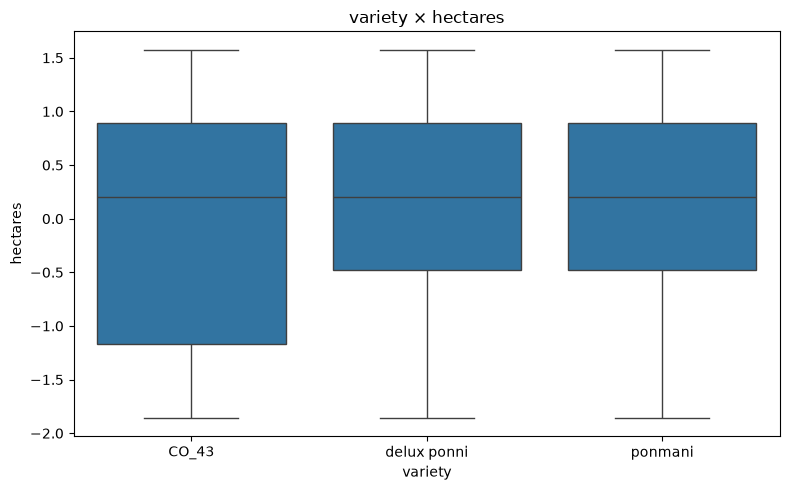

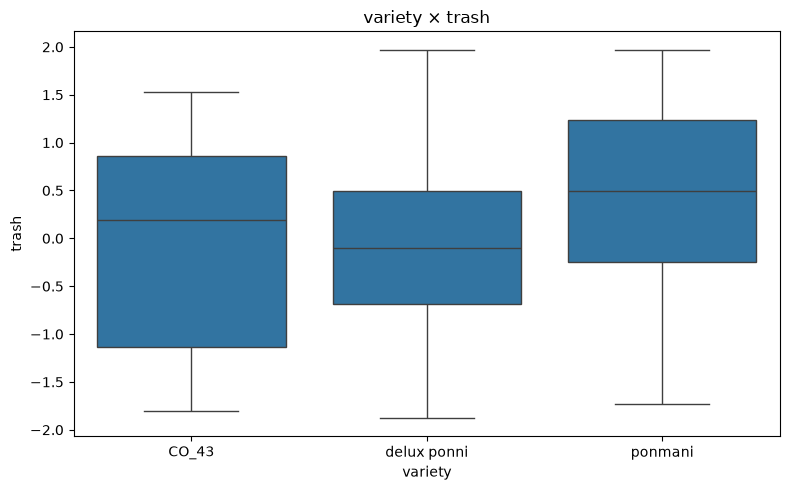

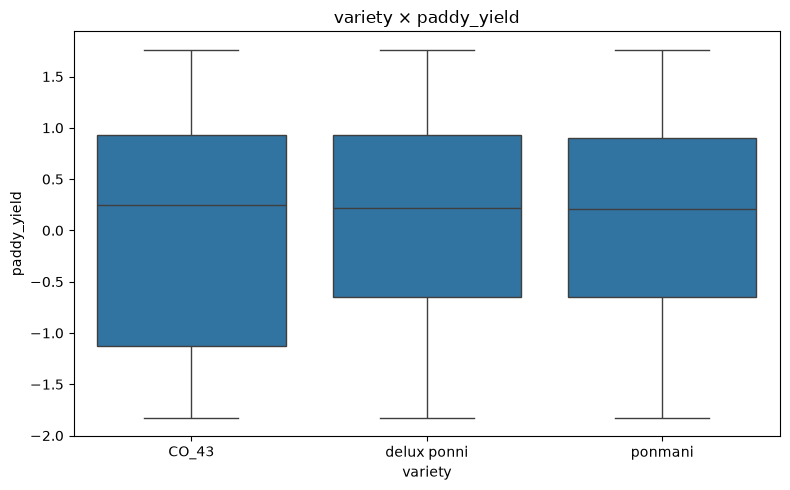

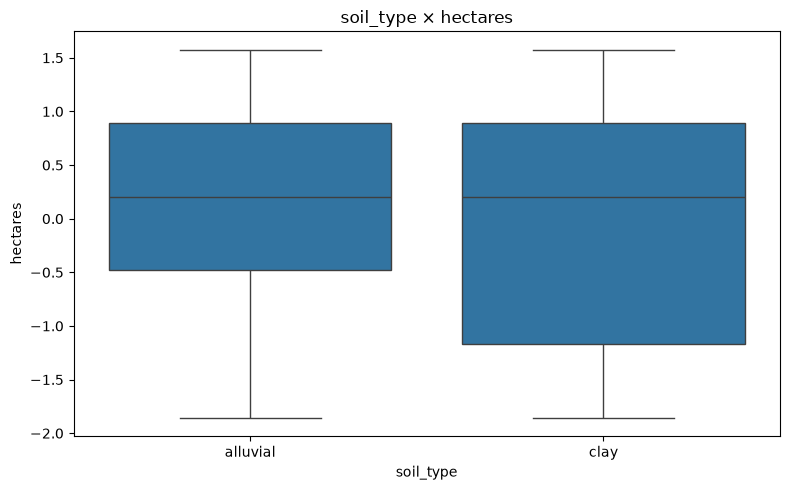

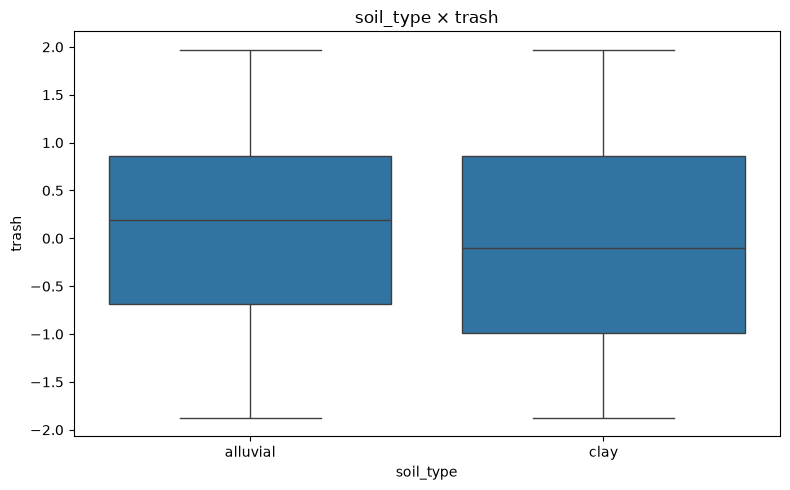

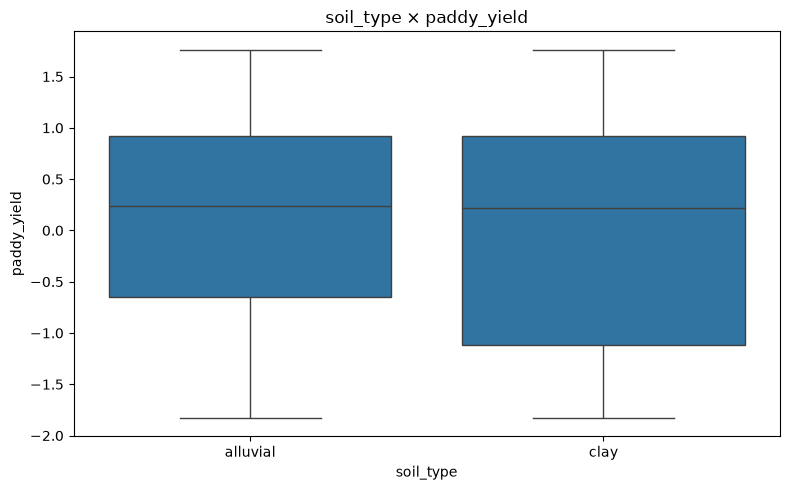

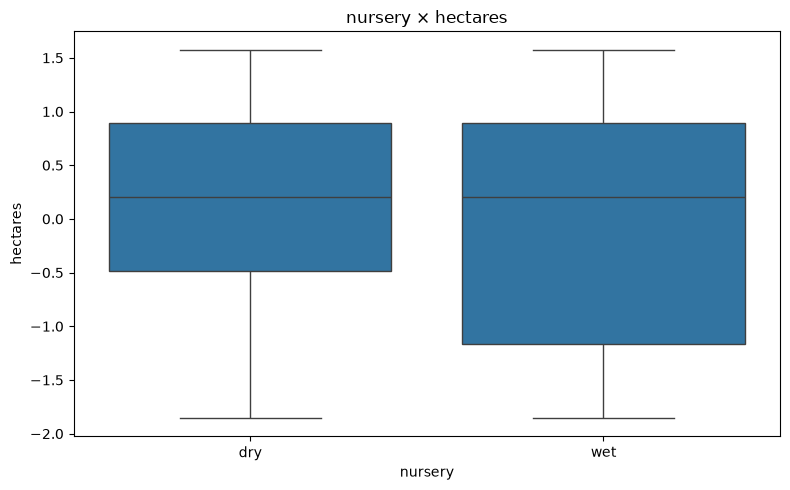

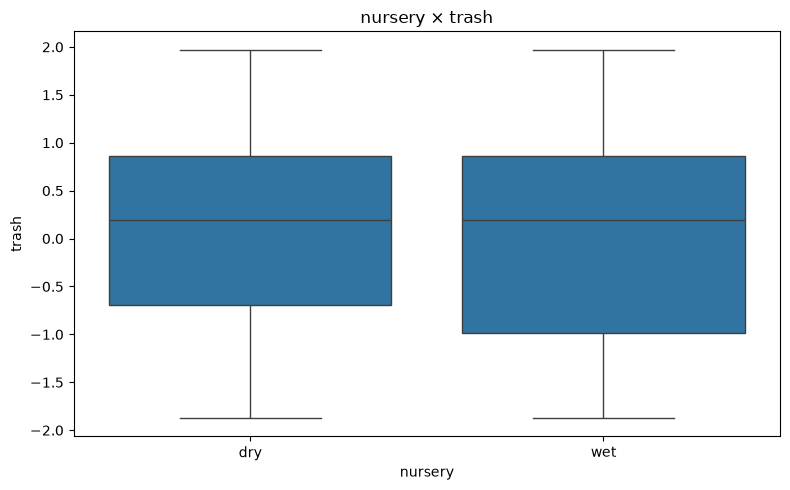

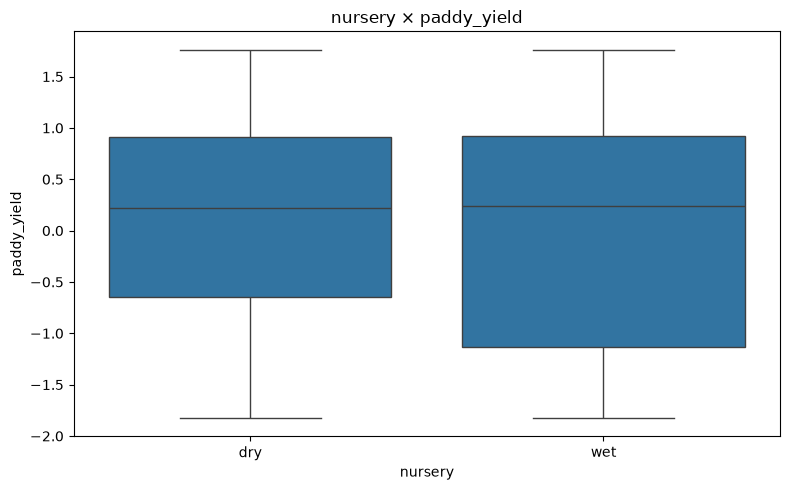

In [68]:
def plot_categorical_numeric_relationships(
    data_frame: pd.DataFrame,
    categorical_columns: list[str],
    numerical_columns: list[str],
):
    for categorical, numerical in product(categorical_columns, numerical_columns):
        plt.figure(figsize=(8, 5))

        sns.boxplot(data=data_frame, x=categorical, y=numerical)

        plt.title(f"{categorical} × {numerical}")
        plt.xlabel(categorical)
        plt.ylabel(numerical)

        plt.tight_layout()
        plt.show()


plot_categorical_numeric_relationships(
    data_frame=f3_df,
    categorical_columns=f3_categorical_columns,
    numerical_columns=[*f3_numerical_columns, *target_columns],
)